In [1]:
!pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 1.5 MB/s eta 0:00:00a 0:00:01


In [6]:
import pandas as pd
import numpy as np
from pygam import LinearGAM, s, te, f
from libpysal.weights import KNN
from esda.moran import Moran
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

df = pd.read_csv('/kaggle/input/datasets/shauryapandey19/spatiotemp/delhi_20station_pm25_spatiotemporal_dataset_final.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df.head())
print(df.shape)

                  timestamp  station_id    station_name operating_agency  \
0 2025-02-18 16:00:00+00:00       10484  aurobindo_marg      DPCC / CPCB   
1 2025-02-18 16:00:00+00:00        5570       aya_nagar       IMD / CPCB   
2 2025-02-18 16:00:00+00:00        8472          bawana      DPCC / CPCB   
3 2025-02-18 16:00:00+00:00        5626             dtu             CPCB   
4 2025-02-18 16:00:00+00:00        5622            nsut             CPCB   

                                   region_type  \
0  Major Traffic Corridor / Institutional Belt   
1         Semi-Urban / Border Residential Belt   
2               Industrial Area / Outer Suburb   
3     Institutional / Educational Complex Zone   
4         Institutional / Suburban Campus Zone   

                                    zone_description  latitude  longitude  \
0  South Delhi / Sri Aurobindo Marg arterial road...  28.53130  77.200100   
1  South Delhi / Ridge & Border Area near Gurugra...  28.47270  77.126500   
2  North We

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245610 entries, 0 to 245609
Data columns (total 38 columns):
 #   Column                   Non-Null Count   Dtype              
---  ------                   --------------   -----              
 0   timestamp                245610 non-null  datetime64[ns, UTC]
 1   station_id               245610 non-null  int64              
 2   station_name             245610 non-null  object             
 3   operating_agency         245610 non-null  object             
 4   region_type              245610 non-null  object             
 5   zone_description         245610 non-null  object             
 6   latitude                 245610 non-null  float64            
 7   longitude                245610 non-null  float64            
 8   timestamp_ist            245610 non-null  object             
 9   temperature_C            245610 non-null  float64            
 10  relative_humidity_pct    245610 non-null  int64              
 11  wind_speed_m_

### Builds PM2.5 lag features (1h, 3h, 6h, 24h) per station using timestamp-exact lookups, so each station's history stays isolated from the others.

In [8]:
# store the finished lag columns in a list of small tables
# one small table per station, then glue them all together at the end
all_station_tables = []

# Get the list of unique station names
all_stations = df['station_name'].unique()

# Go through each station one at a time
for station in all_stations:

    # Get only the rows belonging to this one station
    station_data = df[df['station_name'] == station].copy()

    # Set the timestamp as the index
    # This lets us look up "the row at exactly this timestamp" very easily
    station_data = station_data.set_index('timestamp')

    # Sort by time just to be safe
    station_data = station_data.sort_index()

    # Make a separate small series that only holds the pm25 column
    # indexed by timestamp, since that is all we need for lag lookups
    pm25_by_time = station_data['pm25']

    # Create an empty list to hold the 1-hour lag values for every row
    lag_1h_values = []

    # for 3-hour lag values for every row
    lag_3h_values = []

    # for 6-hour lag values for every row
    lag_6h_values = []

    # for 24-hour lag values 
    lag_24h_values = []

    # Go through every timestamp in this station's data, one at a time
    for current_time in station_data.index:

        # Work out what timestamp was exactly 1 hour earlier
        time_1h_ago = current_time - pd.Timedelta(hours=1)

        # Check if that exact timestamp exists in this station's data
        if time_1h_ago in pm25_by_time.index:
            # If it exists, grab the pm25 value from that exact time
            value_1h = pm25_by_time.loc[time_1h_ago]
        else:
            # If it does not exist, we have no choice but to leave it empty
            value_1h = np.nan

        # Add this value to the list
        lag_1h_values.append(value_1h)

        # Work out what timestamp was exactly 3 hours earlier
        time_3h_ago = current_time - pd.Timedelta(hours=3)

        # Check if that exact timestamp exists
        if time_3h_ago in pm25_by_time.index:
            value_3h = pm25_by_time.loc[time_3h_ago]
        else:
            value_3h = np.nan

        # Add this value to_the list
        lag_3h_values.append(value_3h)

        # Work out what timestamp was exactly 6 hours earlier
        time_6h_ago = current_time - pd.Timedelta(hours=6)

        # Check if that exact timestamp exists
        if time_6h_ago in pm25_by_time.index:
            value_6h = pm25_by_time.loc[time_6h_ago]
        else:
            value_6h = np.nan

        # Add this value to the list
        lag_6h_values.append(value_6h)

        # Work out what timestamp was exactly 24 hours earlier
        time_24h_ago = current_time - pd.Timedelta(hours=24)

        
        if time_24h_ago in pm25_by_time.index:
            value_24h = pm25_by_time.loc[time_24h_ago]
        else:
            value_24h = np.nan

        
        lag_24h_values.append(value_24h)

    # Attach all four lag lists as new columns on this station's table
    station_data['pm25_lag1'] = lag_1h_values
    station_data['pm25_lag3'] = lag_3h_values
    station_data['pm25_lag6'] = lag_6h_values
    station_data['pm25_lag24'] = lag_24h_values

    # Turn the timestamp back into a normal column instead of an index
    station_data = station_data.reset_index()

    # Save this station's finished table into our list
    all_station_tables.append(station_data)

# Glue all the station tables back together into one big table again
df = pd.concat(all_station_tables, ignore_index=True)

# Show how many values are missing in each lag column, just to check
print(df[['pm25_lag1', 'pm25_lag3', 'pm25_lag6', 'pm25_lag24']].isna().sum())

pm25_lag1      1200
pm25_lag3      3471
pm25_lag6      6239
pm25_lag24    11606
dtype: int64


### Calculates the compass bearing from one station to another, used to determine wind alignment between neighboring stations.

In [9]:
# This function works out the compass bearing FROM one point TO another point
# Bearing means "which direction do you have to face to walk from A to B"
# It gives an answer in degrees, where 0 = North, 90 = East, 180 = South, 270 = West
def calculate_bearing(lat_from, lon_from, lat_to, lon_to):

    # Convert all four coordinates from degrees into radians
    # Radians are needed because that is what the math functions expect
    lat_from_rad = np.radians(lat_from)
    lon_from_rad = np.radians(lon_from)
    lat_to_rad = np.radians(lat_to)
    lon_to_rad = np.radians(lon_to)

    # Calculate the difference in longitude between the two points
    delta_lon = lon_to_rad - lon_from_rad

    # This is the standard bearing formula
    # It combines the latitude and longitude differences into one angle
    x = np.sin(delta_lon) * np.cos(lat_to_rad)

    y = (
        np.cos(lat_from_rad) * np.sin(lat_to_rad)
        - np.sin(lat_from_rad) * np.cos(lat_to_rad) * np.cos(delta_lon)
    )

    # atan2 turns the x and y values into a single angle, in radians
    bearing_rad = np.arctan2(x, y)

    # Convert the bearing back from radians into degrees
    bearing_deg = np.degrees(bearing_rad)

    # Bearings from atan2 can come out negative (like -30 degrees)
    # This line wraps any negative angle around to the 0-360 range
    bearing_deg = (bearing_deg + 360) % 360

    # Send the final bearing value back to whoever called this function
    return bearing_deg

### Scores how directly upwind a neighboring station is relative to the target station's current wind direction, returning a value between -1 and 1.

In [10]:
# This function checks how "upwind" a neighbor station is compared to the target
# It returns a number between -1 and 1
# 1 means the neighbor is directly upwind (wind is blowing from them to us)
# -1 means the neighbor is directly downwind (wind is blowing away from us, toward them)
def calculate_alignment(wind_dir_sin, wind_dir_cos, bearing_deg):

    # Convert the bearing from degrees into radians
    bearing_rad = np.radians(bearing_deg)

    # Work out sin and cos of the bearing angle
    bearing_sin = np.sin(bearing_rad)
    bearing_cos = np.cos(bearing_rad)

    # This is the trig identity for cos(wind_direction - bearing)
    # It tells us how closely the wind direction matches the bearing direction
    alignment = (
        wind_dir_cos * bearing_cos
        + wind_dir_sin * bearing_sin
    )

    # Send the alignment score back
    return alignment

### Converts the wind alignment score into a weight multiplier (0.1 to 1.0), giving upwind neighbors more influence than downwind ones.

In [11]:
# This function takes the alignment score (-1 to 1) and turns it into
# a weight multiplier between 0.1 and 1.0
# Upwind neighbors (alignment close to 1) get a multiplier close to 1.0
# Downwind neighbors (alignment close to -1) get a multiplier close to 0.1
# This way downwind stations still count a little, just much less
def alignment_to_multiplier(alignment):

    # Rescale alignment from the -1 to 1 range into the 0 to 1 range
    scaled = (alignment + 1) / 2

    # Now stretch that 0 to 1 range into the 0.1 to 1.0 range 
    multiplier = 0.1 + 0.9 * scaled

    return multiplier

### Defines the function that builds the neighborhood_state feature: a distance- and wind-weighted average of nearby stations' PM2.5, restricted to an allowed set of neighbor stations to prevent leakage.

In [12]:
def build_neighborhood_state(data, grouped_by_time, allowed_stations):

    neighborhood_results = []

    # group the target data by timestamp once, so each group of target rows
    # (same hour) can be matched against the same same_time_rows lookup
    for ts, target_group in data.groupby('timestamp'):

        same_time_rows = grouped_by_time.get(ts)

        if same_time_rows is None:
            for target_station in target_group['station_name']:
                neighborhood_results.append({
                    'station_name': target_station,
                    'timestamp': ts,
                    'neighborhood_state': np.nan
                })
            continue

        # restrict candidate neighbors to allowed_stations only
        same_time_rows = same_time_rows[
            same_time_rows['station_name'].isin(allowed_stations)
        ]
        same_time_rows = same_time_rows.dropna(subset=['pm25'])

        # for each target row in this timestamp group, compute against
        # every candidate neighbor at once using numpy broadcasting
        for _, target_row in target_group.iterrows():

            target_station = target_row['station_name']
            target_lat = target_row['latitude']
            target_lon = target_row['longitude']
            target_wind_sin = target_row['wind_dir_sin']
            target_wind_cos = target_row['wind_dir_cos']

            neighbors = same_time_rows[
                same_time_rows['station_name'] != target_station
            ]

            if len(neighbors) < 1:
                neighborhood_results.append({
                    'station_name': target_station,
                    'timestamp': ts,
                    'neighborhood_state': np.nan
                })
                continue

            neighbor_lat = neighbors['latitude'].values
            neighbor_lon = neighbors['longitude'].values
            neighbor_pm25 = neighbors['pm25'].values

            # --- haversine distance, vectorized (identical formula to original) ---
            lat1 = np.radians(target_lat)
            lon1 = np.radians(target_lon)
            lat2 = np.radians(neighbor_lat)
            lon2 = np.radians(neighbor_lon)

            dlat = lat2 - lat1
            dlon = lon2 - lon1

            a = (
                np.sin(dlat / 2) ** 2
                + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
            )
            distance = 2 * 6371 * np.arcsin(np.sqrt(a))
            distance = np.where(distance == 0, 1e-6, distance)

            # --- bearing + alignment, using the SAME functions as the original ---
            # calculate_bearing/calculate_alignment already use np.* internally,
            # so passing arrays instead of scalars vectorizes them for free
            bearing = calculate_bearing(
                neighbor_lat, neighbor_lon,
                target_lat, target_lon
            )
            alignment = calculate_alignment(
                target_wind_sin, target_wind_cos, bearing
            )
            wind_multiplier = alignment_to_multiplier(alignment)

            distance_weight = 1 / (distance ** 2)
            final_weight = distance_weight * wind_multiplier

            weight_sum = final_weight.sum()
            weighted_pm25_sum = (final_weight * neighbor_pm25).sum()

            neighborhood_state = weighted_pm25_sum / weight_sum

            neighborhood_results.append({
                'station_name': target_station,
                'timestamp': ts,
                'neighborhood_state': neighborhood_state
            })

    return pd.DataFrame(neighborhood_results)

In [13]:
# --- VALIDATION: confirm vectorized version matches original row-by-row version ---
# run on a small subset (2 stations, first 500 timestamps) so the slow
# original version finishes in reasonable time for comparison

def build_neighborhood_state_ORIGINAL(data, grouped_by_time, allowed_stations):
    neighborhood_results = []
    for _, target_row in data.iterrows():
        target_station = target_row['station_name']
        ts = target_row['timestamp']
        target_lat = target_row['latitude']
        target_lon = target_row['longitude']
        target_wind_sin = target_row['wind_dir_sin']
        target_wind_cos = target_row['wind_dir_cos']

        same_time_rows = grouped_by_time.get(ts)
        if same_time_rows is None:
            neighborhood_results.append({'station_name': target_station, 'timestamp': ts, 'neighborhood_state': np.nan})
            continue

        same_time_rows = same_time_rows[same_time_rows['station_name'].isin(allowed_stations)]
        neighbors = same_time_rows[same_time_rows['station_name'] != target_station]
        neighbors = neighbors.dropna(subset=['pm25'])

        if len(neighbors) < 1:
            neighborhood_results.append({'station_name': target_station, 'timestamp': ts, 'neighborhood_state': np.nan})
            continue

        weighted_pm25_sum = 0
        weight_sum = 0
        for _, neighbor in neighbors.iterrows():
            lat1 = np.radians(target_lat)
            lon1 = np.radians(target_lon)
            lat2 = np.radians(neighbor['latitude'])
            lon2 = np.radians(neighbor['longitude'])
            dlat = lat2 - lat1
            dlon = lon2 - lon1
            a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
            distance = 2 * 6371 * np.arcsin(np.sqrt(a))
            if distance == 0:
                distance = 1e-6
            bearing = calculate_bearing(neighbor['latitude'], neighbor['longitude'], target_lat, target_lon)
            alignment = calculate_alignment(target_wind_sin, target_wind_cos, bearing)
            wind_multiplier = alignment_to_multiplier(alignment)
            distance_weight = 1 / (distance ** 2)
            final_weight = distance_weight * wind_multiplier
            weighted_pm25_sum += final_weight * neighbor['pm25']
            weight_sum += final_weight

        neighborhood_state = weighted_pm25_sum / weight_sum
        neighborhood_results.append({'station_name': target_station, 'timestamp': ts, 'neighborhood_state': neighborhood_state})

    return pd.DataFrame(neighborhood_results)


# small subset: first 500 unique timestamps, all stations allowed
subset_timestamps = sorted(df['timestamp'].unique())[:500]
subset_df = df[df['timestamp'].isin(subset_timestamps)].copy()
subset_grouped_by_time = dict(tuple(subset_df.groupby('timestamp')))
subset_allowed_stations = subset_df['station_name'].unique()

test_rows = subset_df[subset_df['station_name'].isin(subset_df['station_name'].unique()[:2])]

result_original = build_neighborhood_state_ORIGINAL(test_rows, subset_grouped_by_time, subset_allowed_stations)
result_vectorized = build_neighborhood_state(test_rows, subset_grouped_by_time, subset_allowed_stations)

merged_check = result_original.merge(
    result_vectorized, on=['station_name', 'timestamp'], suffixes=('_orig', '_vec')
)
merged_check['diff'] = (merged_check['neighborhood_state_orig'] - merged_check['neighborhood_state_vec']).abs()

print("Max absolute difference:", merged_check['diff'].max())
print("Rows compared:", len(merged_check))
print(merged_check.sort_values('diff', ascending=False).head())

Max absolute difference: 8.526512829121202e-14
Rows compared: 939
       station_name                 timestamp  neighborhood_state_orig  \
179  aurobindo_marg 2025-02-26 03:00:00+00:00               178.619891   
488  aurobindo_marg 2025-03-11 00:00:00+00:00               150.740312   
490  aurobindo_marg 2025-03-11 02:00:00+00:00               163.055883   
494  aurobindo_marg 2025-03-11 06:00:00+00:00               109.870123   
670       aya_nagar 2025-02-25 18:00:00+00:00               128.029656   

     neighborhood_state_vec          diff  
179              178.619891  8.526513e-14  
488              150.740312  8.526513e-14  
490              163.055883  5.684342e-14  
494              109.870123  5.684342e-14  
670              128.029656  5.684342e-14  


### Converts timestamp into a numeric hours-since-start value and assembles the core feature table used for the GAM, dropping rows with no target value.

In [14]:
# Create a new numeric column that represents time as a plain number
# GAM smooth functions need a number to work with, not a raw date
# hours since the very first timestamp in the data
earliest_time = df['timestamp'].min()

# Work out the time difference for every row, then convert it to hours
df['time_numeric'] = (df['timestamp'] - earliest_time).dt.total_seconds() / 3600

# pick out only the columns we actually use for the GAM
gam_table = df[[
    'pm25_original',
    'timestamp',
    'time_numeric',
    'station_name',
    'latitude',
    'longitude',
    'boundary_layer_height_m',
    'wind_speed_m_s',
    'wind_dir_sin',
    'wind_dir_cos',
    'pm25_lag1',
    'pm25_lag3',
    'pm25_lag6',
    'pm25_lag24',
    'pm25_was_interpolated'
]].copy()


print(gam_table.shape)

# Drop rows where the target value itself is missing
# cannot train or test on a row where we do not know the true answer
gam_table = gam_table.dropna(subset=['pm25_original'])


print(gam_table.shape)
print(gam_table.isna().sum())

(245610, 15)
(235900, 15)
pm25_original                  0
timestamp                      0
time_numeric                   0
station_name                   0
latitude                       0
longitude                      0
boundary_layer_height_m        0
wind_speed_m_s                 0
wind_dir_sin                   0
wind_dir_cos                   0
pm25_lag1                    743
pm25_lag3                   2096
pm25_lag6                   5005
pm25_lag24                 10619
pm25_was_interpolated          0
dtype: int64


In [15]:
required_columns = [
    'pm25_original',
    'boundary_layer_height_m',
    'wind_speed_m_s',
    'wind_dir_sin',
    'wind_dir_cos',
    'pm25_lag1',
    'pm25_lag3',
    'pm25_lag6',
    'pm25_lag24'
]

print(gam_table.shape)

# Only keep rows where every single one of these columns has a real value
# This way every row entering the GAM is on equal footing
gam_table = gam_table.dropna(subset=required_columns)

print(gam_table.shape)

print(gam_table.isna().sum())

(235900, 15)
(221197, 15)
pm25_original              0
timestamp                  0
time_numeric               0
station_name               0
latitude                   0
longitude                  0
boundary_layer_height_m    0
wind_speed_m_s             0
wind_dir_sin               0
wind_dir_cos               0
pm25_lag1                  0
pm25_lag3                  0
pm25_lag6                  0
pm25_lag24                 0
pm25_was_interpolated      0
dtype: int64


### Encodes station identity as a numeric code and defines the ordered list of feature columns and the target variable for the GAM.

In [16]:
gam_table['station_name'] = gam_table['station_name'].astype('category')


# pyGAM needs station_name turned into numeric codes, not text
# f() (factor term) will treat this as a categorical variable later
gam_table['station_code'] = gam_table['station_name'].cat.codes

# Pull out the target variable on its own
y = gam_table['pm25_original'].values

# Build the feature matrix in a fixed column order
# This order matters because we will refer to columns by position number below
feature_columns = [
    'time_numeric',
    'boundary_layer_height_m',
    'wind_speed_m_s',
    'wind_dir_sin',
    'wind_dir_cos',
    'latitude',
    'longitude',
    'pm25_lag1',
    'pm25_lag3',
    'pm25_lag6',
    'pm25_lag24',
    'neighborhood_state'   
]



### Defines the GAM's smooth and tensor terms, mapped to each feature's position in the feature matrix.

In [17]:
# 0  = time_numeric
# 1  = boundary_layer_height_m
# 2  = wind_speed_m_s
# 3  = wind_dir_sin
# 4  = wind_dir_cos
# 5  = latitude
# 6  = longitude
# 7  = pm25_lag1
# 8  = pm25_lag3
# 9  = pm25_lag6
# 10 = pm25_lag24
# 11 = neighborhood_state
 

gam_terms = (
    s(0)
    + s(1)
    + s(2)
    + te(3, 4)
    + te(5, 6)
    + s(7)
    + s(8)
    + s(9)
    + s(10)
    + s(11)   
)

### Runs leave-one-station-out validation: for each held-out station, rebuilds neighborhood_state using only the training stations, fits the GAM, and stores predictions.

In [18]:
# group all rows by timestamp once, so we can quickly look up
# "who else reported at this same hour" inside the loop below
grouped_by_time = dict(tuple(df.groupby('timestamp')))

loso_results = []

all_stations = gam_table['station_name'].unique()

# LOSO = Leave One Station Out
# each pass through this loop, one station is fully held out
for held_out_station in all_stations:

    # these are the only stations allowed to act as "neighbors" this fold
    training_stations = []
    for station in all_stations:
        if station != held_out_station:
            training_stations.append(station)

    train_rows = gam_table[gam_table['station_name'] != held_out_station].copy()
    test_rows = gam_table[gam_table['station_name'] == held_out_station].copy()

    if len(test_rows) < 1:
        continue

    # neighborhood_state gets built fresh here, only from training_stations,
    # so the held-out station can never leak into it
    train_neighborhood = build_neighborhood_state(
        train_rows, grouped_by_time, training_stations
    )
    test_neighborhood = build_neighborhood_state(
        test_rows, grouped_by_time, training_stations
    )

    # attach the fresh neighborhood_state values onto train/test rows
    train_rows = train_rows.merge(
        train_neighborhood, on=['station_name', 'timestamp'], how='left'
    )
    test_rows = test_rows.merge(
        test_neighborhood, on=['station_name', 'timestamp'], how='left'
    )

    train_rows = train_rows.dropna(subset=['neighborhood_state'])
    test_rows = test_rows.dropna(subset=['neighborhood_state'])

    if len(test_rows) < 1:
        continue

    X_train = train_rows[feature_columns].values
    y_train = train_rows['pm25_original'].values

    X_test = test_rows[feature_columns].values
    y_test = test_rows['pm25_original'].values

    gam_model = LinearGAM(gam_terms)
    gam_model.fit(X_train, y_train)

    y_pred = gam_model.predict(X_test)

    # store one row per prediction, so we can score everything after the loop
    for i in range(len(y_test)):
        loso_results.append({
            'station_name': held_out_station,
            'actual': y_test[i],
            'predicted': y_pred[i]
        })

    print(held_out_station)

aurobindo_marg
aya_nagar
bawana
dtu
nsut
punjabi_bagh
pusa
rk_puram
sonia_vihar
anand_vihar
mandir_marg
wazirpur
alipur
narela
najafgarh
okhla_phase_2
vivek_vihar
rohini
patparganj
mundka


In [19]:
loso_df = pd.DataFrame(loso_results)  # turn all saved predictions into one table

y_true = loso_df['actual']  # true pm2.5 values across every held-out station
y_pred = loso_df['predicted']  # predicted pm2.5 values across every held-out station

mae = mean_absolute_error(y_true, y_pred)  # average absolute size of the error
rmse = mean_squared_error(y_true, y_pred) ** 0.5  # penalizes large errors more heavily than MAE
r2 = r2_score(y_true, y_pred)  # how much of the variation the model explains, 1.0 is perfect
bias = (y_pred - y_true).mean()  # positive means the model tends to overpredict, negative means underpredict

print(f"Total predictions made: {len(loso_df)}")
print(f"GAM MAE:   {mae:.2f}")
print(f"GAM RMSE:  {rmse:.2f}")
print(f"GAM R2:    {r2:.3f}")
print(f"GAM Bias:  {bias:.2f}")

Total predictions made: 221175
GAM MAE:   15.64
GAM RMSE:  25.27
GAM R2:    0.911
GAM Bias:  -2.26


In [20]:
loso_df.to_csv('/kaggle/working/loso_df_20station.csv', index=False)

In [21]:
per_station_results = []  # will hold one summary row per station

for station in loso_df['station_name'].unique():  # go through each station's results separately

    station_rows = loso_df[loso_df['station_name'] == station]  # only this station's predictions

    station_mae = mean_absolute_error(station_rows['actual'], station_rows['predicted'])  # this station's average error size
    station_rmse = mean_squared_error(station_rows['actual'], station_rows['predicted']) ** 0.5  # this station's penalized error
    station_r2 = r2_score(station_rows['actual'], station_rows['predicted'])  # how well the model explains this station alone
    station_bias = (station_rows['predicted'] - station_rows['actual']).mean()  # over or under prediction for this station

    per_station_results.append({  # save this station's summary row
        'station_name': station,
        'MAE': station_mae,
        'RMSE': station_rmse,
        'R2': station_r2,
        'Bias': station_bias,
        'n_test_points': len(station_rows)
    })

per_station_df = pd.DataFrame(per_station_results)  # combine all station summaries into one table

print(per_station_df)

      station_name        MAE       RMSE        R2       Bias  n_test_points
0   aurobindo_marg   9.699374  14.827814  0.938593   6.785970          11355
1        aya_nagar  19.705519  27.292652  0.838062 -14.909931           7439
2           bawana  33.548491  40.130162  0.827855 -31.114146          11696
3              dtu  16.921791  38.325652  0.843447   7.628625           8751
4             nsut  19.892325  43.722274  0.643137  -4.046840          11325
5     punjabi_bagh  12.172938  19.547021  0.950380  -0.740316          11363
6             pusa  12.854105  22.526965  0.892044   2.551151           9054
7         rk_puram  14.797058  27.145573  0.904839  -8.559770          11436
8      sonia_vihar  12.886277  21.478292  0.934094  -5.611198          11585
9      anand_vihar  14.652137  21.969775  0.944610  -3.049204          11503
10     mandir_marg  15.109424  20.376681  0.897328  -8.433332          10756
11        wazirpur  15.227958  21.960313  0.947882   6.826401          11664

In [22]:
#check performance for low & high pm2.5 days
low_mask = loso_df['actual'] < 100
high_mask = loso_df['actual'] >= 100

low_mae = mean_absolute_error(loso_df[low_mask]['actual'], loso_df[low_mask]['predicted'])
low_rmse = mean_squared_error(loso_df[low_mask]['actual'], loso_df[low_mask]['predicted']) ** 0.5

high_mae = mean_absolute_error(loso_df[high_mask]['actual'], loso_df[high_mask]['predicted'])
high_rmse = mean_squared_error(loso_df[high_mask]['actual'], loso_df[high_mask]['predicted']) ** 0.5

print(f"Low PM2.5 (<100)  MAE: {low_mae:.2f}  RMSE: {low_rmse:.2f}  n={low_mask.sum()}")
print(f"High PM2.5 (>=100) MAE: {high_mae:.2f}  RMSE: {high_rmse:.2f}  n={high_mask.sum()}")

Low PM2.5 (<100)  MAE: 12.09  RMSE: 16.91  n=162836
High PM2.5 (>=100) MAE: 25.56  RMSE: 40.29  n=58339


# =========================================
#             MIXED-EFFECTS
# =========================================

### Per-station residual bias
Average leftover error (predicted − actual) per station from the LOSO results. This is the "baseline offset" a random intercept would estimate.

In [23]:
loso_df['residual'] = loso_df['predicted'] - loso_df['actual']

station_residuals = loso_df.groupby('station_name')['residual'].agg(['mean', 'std', 'count'])
station_residuals.columns = ['mean_bias', 'residual_std', 'n']

print(station_residuals)

                mean_bias  residual_std      n
station_name                                  
alipur         -14.018457     17.309347  11292
anand_vihar     -3.049204     21.758091  11503
aurobindo_marg   6.785970     13.184460  11355
aya_nagar      -14.909931     22.861607   7439
bawana         -31.114146     25.345506  11696
dtu              7.628625     37.560896   8751
mandir_marg     -8.433332     18.550472  10756
mundka           5.755285     22.835582  11757
najafgarh        5.201039     15.551901  11313
narela          11.695560     22.571894  12081
nsut            -4.046840     43.536510  11325
okhla_phase_2  -12.926102     15.012982  11655
patparganj       8.142652     15.376601  11699
punjabi_bagh    -0.740316     19.533856  11363
pusa             2.551151     22.383277   9054
rk_puram        -8.559770     25.761803  11436
rohini          -6.096469     19.924486  12073
sonia_vihar     -5.611198     20.733272  11585
vivek_vihar      7.942406     19.804841  11378
wazirpur     

### One-sample t-test per station, checking if the average residual is significantly different from zero (vs. just noise).

In [24]:
from scipy import stats

t_test_results = []

for station in loso_df['station_name'].unique():
    station_resid = loso_df[loso_df['station_name'] == station]['residual']

    # one-sample t-test: is this station's average residual meaningfully different from 0?
    t_stat, p_value = stats.ttest_1samp(station_resid, 0)

    t_test_results.append({
        'station_name': station,
        'mean_bias': station_resid.mean(),
        't_stat': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05  # small p-value = bias is unlikely to be random chance
    })

t_test_df = pd.DataFrame(t_test_results)
print(t_test_df)

      station_name  mean_bias      t_stat        p_value  significant
0   aurobindo_marg   6.785970   54.845775   0.000000e+00         True
1        aya_nagar -14.909931  -56.250468   0.000000e+00         True
2           bawana -31.114146 -132.762553   0.000000e+00         True
3              dtu   7.628625   18.999368   6.600175e-79         True
4             nsut  -4.046840   -9.891940   5.591166e-23         True
5     punjabi_bagh  -0.740316   -4.039944   5.381573e-05         True
6             pusa   2.551151   10.845081   3.093319e-27         True
7         rk_puram  -8.559770  -35.532267  2.098224e-262         True
8      sonia_vihar  -5.611198  -29.129684  4.272783e-180         True
9      anand_vihar  -3.049204  -15.030425   1.400558e-50         True
10     mandir_marg  -8.433332  -47.148691   0.000000e+00         True
11        wazirpur   6.826401   35.320373  1.022443e-259         True
12          alipur -14.018457  -86.060720   0.000000e+00         True
13          narela  

### Variance decomposition (ICC)
Splits total residual variance into between-station (location effect) and within-station (time-varying conditions/noise), and reports what share is due to station identity.

In [25]:
station_means = loso_df.groupby('station_name')['residual'].mean()

between_station_var = station_means.var(ddof=1)
within_station_var = loso_df.groupby('station_name')['residual'].var().mean()

icc = between_station_var / (between_station_var + within_station_var)

print(f"Between-station variance: {between_station_var:.3f}")
print(f"Within-station variance:  {within_station_var:.3f}")
print(f"ICC (share of variance explained by station identity): {icc:.3f}")

Between-station variance: 114.033
Within-station variance:  534.898
ICC (share of variance explained by station identity): 0.176


## Moran's I on station residual bias
Tests whether stations that are geographically close also have similar leftover bias — i.e. whether spatial structure remains after `te(lat,lon)` in the GAM.

In [26]:
station_coords = df[['station_name', 'latitude', 'longitude']].drop_duplicates(subset='station_name').reset_index(drop=True)

In [27]:


station_coords = station_coords.merge(
    station_residuals[['mean_bias']],
    on='station_name',
    how='left'
)

print(station_coords)

coords = station_coords[['longitude', 'latitude']].values

# each station's bias "sees" its k nearest neighbors when checking spatial pattern
w = KNN.from_array(coords, k=3)
w.transform = 'r'

# align bias values to the same station order as coords
bias_values = station_coords['mean_bias'].values

moran = Moran(bias_values, w)

print(f"Moran's I: {moran.I:.3f}")
print(f"p-value: {moran.p_sim:.3f}")

      station_name  latitude  longitude  mean_bias
0   aurobindo_marg  28.53130  77.200100   6.785970
1        aya_nagar  28.47270  77.126500 -14.909931
2           bawana  28.77620  77.051100 -31.114146
3              dtu  28.75005  77.111261   7.628625
4             nsut  28.60900  77.032500  -4.046840
5     punjabi_bagh  28.67400  77.131000  -0.740316
6             pusa  28.63960  77.146200   2.551151
7         rk_puram  28.56420  77.177000  -8.559770
8      sonia_vihar  28.72500  77.249000  -5.611198
9      anand_vihar  28.64690  77.316000  -3.049204
10     mandir_marg  28.63600  77.201000  -8.433332
11        wazirpur  28.69970  77.165400   6.826401
12          alipur  28.79720  77.133100 -14.018457
13          narela  28.82280  77.101900  11.695560
14       najafgarh  28.57020  76.933800   5.201039
15   okhla_phase_2  28.53080  77.271200 -12.926102
16     vivek_vihar  28.67230  77.315300   7.942406
17          rohini  28.73250  77.119900  -6.096469
18      patparganj  28.62380  7

In [28]:
station_residuals.to_csv('/kaggle/working/station_residuals_20station.csv', index=False)

Total pairs: 190
       distance_km  semivariance
count   190.000000    190.000000
mean     18.264845    114.032689
std       8.527396    166.519502
min       2.125447      0.000817
25%      11.616275     10.115184
50%      17.517880     58.563558
75%      24.445184    138.959495
max      39.003287    916.335486
       distance_bin  avg_distance  avg_semivariance  n_pairs
0    (2.089, 8.272]      5.918537        135.060278       24
1   (8.272, 14.418]     11.410814        105.014300       47
2  (14.418, 20.564]     17.386232         78.597091       44
3  (20.564, 26.711]     23.530693        103.400384       42
4  (26.711, 32.857]     29.245065        202.589025       22
5  (32.857, 39.003]     35.935692        111.913233       11


/tmp/ipykernel_58/155727130.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  variogram = pairs_df.groupby('distance_bin').agg(


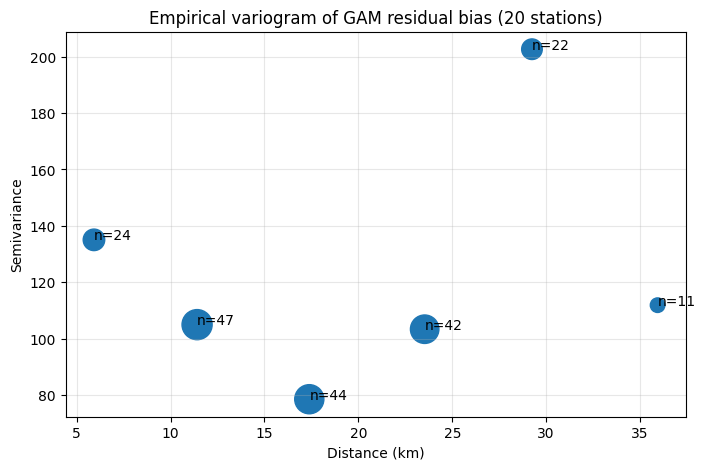

In [29]:
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# pairwise distances between all 20 stations (in km, using haversine)
def haversine_matrix(lats, lons):
    lats_rad = np.radians(lats)
    lons_rad = np.radians(lons)
    n = len(lats)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        dlat = lats_rad - lats_rad[i]
        dlon = lons_rad - lons_rad[i]
        a = np.sin(dlat/2)**2 + np.cos(lats_rad[i])*np.cos(lats_rad)*np.sin(dlon/2)**2
        dist_matrix[i] = 2 * 6371 * np.arcsin(np.sqrt(a))
    return dist_matrix

lats = station_coords['latitude'].values
lons = station_coords['longitude'].values
bias = station_coords['mean_bias'].values

dist_matrix = haversine_matrix(lats, lons)

# build all unique pairs (i < j) with their distance and squared bias difference
pairs = []
n = len(bias)
for i in range(n):
    for j in range(i+1, n):
        pairs.append({
            'distance_km': dist_matrix[i, j],
            'semivariance': 0.5 * (bias[i] - bias[j])**2
        })

pairs_df = pd.DataFrame(pairs)
print(f"Total pairs: {len(pairs_df)}")
print(pairs_df.describe())

# bin by distance and average semivariance per bin (empirical variogram)
n_bins = 6
pairs_df['distance_bin'] = pd.cut(pairs_df['distance_km'], bins=n_bins)

variogram = pairs_df.groupby('distance_bin').agg(
    avg_distance=('distance_km', 'mean'),
    avg_semivariance=('semivariance', 'mean'),
    n_pairs=('semivariance', 'count')
).reset_index()

print(variogram)

# plot
plt.figure(figsize=(8, 5))
plt.scatter(variogram['avg_distance'], variogram['avg_semivariance'], s=variogram['n_pairs']*10)
for _, row in variogram.iterrows():
    plt.annotate(f"n={int(row['n_pairs'])}", (row['avg_distance'], row['avg_semivariance']))
plt.xlabel('Distance (km)')
plt.ylabel('Semivariance')
plt.title('Empirical variogram of GAM residual bias (20 stations)')
plt.grid(alpha=0.3)
plt.show()

Total pairs: 190
       wind_alignment  semivariance
count      190.000000    190.000000
mean         0.080140    114.032689
std          0.055349    166.519502
min         -0.056809      0.000817
25%          0.044897     10.115184
50%          0.089403     58.563558
75%          0.128438    138.959495
max          0.165698    916.335486
       alignment_bin  avg_alignment  avg_semivariance  n_pairs
0  (-0.057, -0.0197]      -0.033929        108.294371       15
1  (-0.0197, 0.0174]       0.003771        105.532608       20
2   (0.0174, 0.0544]       0.037544         98.416195       18
3   (0.0544, 0.0915]       0.074015         71.958802       44
4    (0.0915, 0.129]       0.111781        120.251961       46
5     (0.129, 0.166]       0.140122        158.763282       47


/tmp/ipykernel_58/2824763385.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_variogram = wind_pairs_df.groupby('alignment_bin').agg(


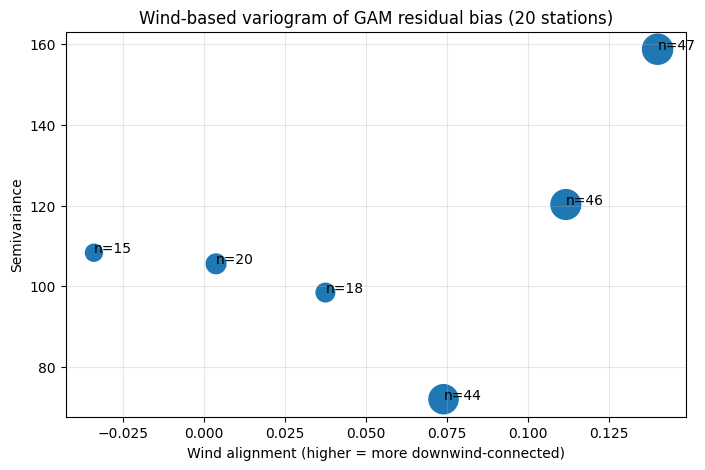

In [30]:
# --- WIND-BASED VARIOGRAM: test if wind alignment explains residual bias better than distance ---

# for each station pair, compute a wind-transport alignment score using
# each station's own average wind direction (sin/cos), reusing the same
# calculate_bearing and calculate_alignment functions already in the notebook

# first, get each station's average wind direction (as sin/cos, then averaged properly)
station_wind = df.groupby('station_name').agg(
    avg_wind_sin=('wind_dir_sin', 'mean'),
    avg_wind_cos=('wind_dir_cos', 'mean')
).reset_index()

# merge onto station_coords so we have lat, lon, mean_bias, and wind in one table
station_full = station_coords.merge(station_wind, on='station_name', how='left')

lats = station_full['latitude'].values
lons = station_full['longitude'].values
bias = station_full['mean_bias'].values
wind_sin = station_full['avg_wind_sin'].values
wind_cos = station_full['avg_wind_cos'].values

n = len(station_full)

wind_pairs = []

for i in range(n):
    for j in range(i + 1, n):

        # is station i UPWIND of j (does j's wind come FROM i's direction)?
        # check j's wind against the bearing pointing FROM j BACK TO i
        bearing_j_to_i = calculate_bearing(lats[j], lons[j], lats[i], lons[i])
        alignment_i_transports_to_j = calculate_alignment(wind_sin[j], wind_cos[j], bearing_j_to_i)

        # is station j UPWIND of i (does i's wind come FROM j's direction)?
        # check i's wind against the bearing pointing FROM i BACK TO j
        bearing_i_to_j = calculate_bearing(lats[i], lons[i], lats[j], lons[j])
        alignment_j_transports_to_i = calculate_alignment(wind_sin[i], wind_cos[i], bearing_i_to_j)

        # overall pair alignment: take the stronger of the two transport directions
        # (captures "is there a dominant wind transport link between these two, in either direction")
        pair_alignment = max(alignment_i_transports_to_j, alignment_j_transports_to_i)

        semivariance = 0.5 * (bias[i] - bias[j]) ** 2

        wind_pairs.append({
            'station_a': station_full['station_name'].iloc[i],
            'station_b': station_full['station_name'].iloc[j],
            'wind_alignment': pair_alignment,
            'semivariance': semivariance
        })

wind_pairs_df = pd.DataFrame(wind_pairs)
print(f"Total pairs: {len(wind_pairs_df)}")
print(wind_pairs_df.describe())

# bin by wind alignment instead of distance
n_bins = 6
wind_pairs_df['alignment_bin'] = pd.cut(wind_pairs_df['wind_alignment'], bins=n_bins)

wind_variogram = wind_pairs_df.groupby('alignment_bin').agg(
    avg_alignment=('wind_alignment', 'mean'),
    avg_semivariance=('semivariance', 'mean'),
    n_pairs=('semivariance', 'count')
).reset_index()

print(wind_variogram)

plt.figure(figsize=(8, 5))
plt.scatter(wind_variogram['avg_alignment'], wind_variogram['avg_semivariance'], s=wind_variogram['n_pairs'] * 10)
for _, row in wind_variogram.iterrows():
    plt.annotate(f"n={int(row['n_pairs'])}", (row['avg_alignment'], row['avg_semivariance']))
plt.xlabel('Wind alignment (higher = more downwind-connected)')
plt.ylabel('Semivariance')
plt.title('Wind-based variogram of GAM residual bias (20 stations)')
plt.grid(alpha=0.3)
plt.show()